# Token-temperature scan — both models (nano-hep + HEP4M)

Unified tinker notebook. Loads both models, runs temperature sweeps with the **same** PflowMetrics backend (HEP4M VQ-VAE + `run_report_from_arrays`), and plots in-place.

Requires `hep4m2` conda env. Run on a GPU node (A100-80GB; 40GB-class works if both models aren't loaded simultaneously).

**Structure:**
1. Setup + paths
2. Load the two inference modules (scripts-as-libs) and install temperature patches on HEP4M
3. **Load models** — run the one(s) you want to tinker with (nano-hep only, HEP4M only, or both)
4. Run T-scans (edit `T_GRID` and re-run)
5. Plot single-model curves inline
6. Overlay comparison (needs both CSVs)
7. Diagnostics: N-residual histograms, predicted-vs-truth scatters, event-level jet-pt distributions

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib inline

import sys, importlib, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

NANO = Path('/global/cfs/cdirs/m4958/usr/danieltm/Side_Work/FoundationModels/nano-hep')
HEP4M = Path('/global/cfs/cdirs/m4958/usr/danieltm/Side_Work/FoundationModels/HEP4M')
# Put the REPO ROOTS on sys.path so the scripts' internal imports (model, nano_hep.*, hep4m.*) resolve.
# We do NOT put the notebook dirs on sys.path because both contain a file named
# `token_temperature_scan.py` and a plain `import` would be ambiguous.
for p in (str(NANO), str(HEP4M)):
    if p not in sys.path:
        sys.path.insert(0, p)

# Load BOTH scripts by explicit file path under distinct module names to avoid
# the basename collision. (Earlier setup used `import token_temperature_scan`
# which resolved to whichever notebook dir happened to come first on sys.path.)
import importlib.util as _iu
def _load_by_path(name, path):
    spec = _iu.spec_from_file_location(name, str(path))
    mod  = _iu.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

nano_tts  = _load_by_path('nano_tts',  NANO  / 'notebooks/token_temperature_scan.py')
hep4m_tts = _load_by_path('hep4m_tts', HEP4M / 'notebooks/paper/token_temperature_scan.py')
pcmp      = _load_by_path('pcmp',      NANO  / 'notebooks/plot_T_scan_comparison.py')

# Install the HEP4M temperature monkey-patches exactly once.
hep4m_tts._install_patches()

# Sanity: show which file backs each alias
print('nano_tts  <-', nano_tts.__file__)
print('hep4m_tts <-', hep4m_tts.__file__)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device, '|', torch.cuda.get_device_name(0) if device == 'cuda' else '-')

nano_tts  <- /global/cfs/cdirs/m4958/usr/danieltm/Side_Work/FoundationModels/nano-hep/notebooks/token_temperature_scan.py
hep4m_tts <- /global/cfs/cdirs/m4958/usr/danieltm/Side_Work/FoundationModels/HEP4M/notebooks/paper/token_temperature_scan.py
device: cuda | NVIDIA A100-PCIE-40GB


## 2. Shared config — sets defaults used by both models

In [2]:
# N_EVENTS = 2048
N_EVENTS = 128
SEED    = 42
OUT_NANO  = NANO  / 'notebooks/results_T_scan_nb'
OUT_HEP4M = HEP4M / 'notebooks/paper/results_T_scan_nb'
OUT_NANO.mkdir(parents=True, exist_ok=True)
OUT_HEP4M.mkdir(parents=True, exist_ok=True)

## 3a. Load nano-hep (run only if tinkering with nano-hep)

In [3]:
NANO_CKPT = NANO / 'runs/nano_hep_89M_ddp/best.ckpt'
print(f'loading nano-hep ckpt @ mtime {NANO_CKPT.stat().st_mtime}')
nano_model, nano_vocab, nano_cfg, nano_step = nano_tts.load_model_from_ckpt(NANO_CKPT, device=device)
nano_val_ds = nano_tts.build_val_ds(nano_cfg, nano_vocab, max_events=N_EVENTS)
nano_pflow = nano_tts.PflowMetrics(
    modality_dict_path=nano_cfg['pflow_metrics']['modality_dict_path'],
    output_modality=nano_cfg['data']['output_modality'], device=device,
)
print(f'nano: step={nano_step}  block_size={nano_val_ds.block_size}  vocab={nano_vocab.total}')

loading nano-hep ckpt @ mtime 1777239417.983903
number of parameters: 93.51M
nano: step=495000  block_size=512  vocab=11141


## 3b. Load HEP4M (run only if tinkering with HEP4M)

N.B. HEP4M's PflowMetrics is the same backend — but built against HEP4M's modality_dict, so we reuse it here and it's the one we pass to HEP4M's `run_one_T`. (Nano-hep's pflow object is bound to the **same** HEP4M pilot modality_dict too, so numerically identical — you could pass either.)

In [4]:
HEP4M_EXP = HEP4M / 'data/experiments/HEP4M-pflow-gold/pflow_goldxxx2dkwsx0kibyasjqnp5l'
HEP4M_CKPT = HEP4M_EXP / 'checkpoints/epoch=267-val_total_loss=7.5131.ckpt'
print(f'loading HEP4M ckpt @ mtime {HEP4M_CKPT.stat().st_mtime}')
# load_hep4m returns (lit, config_t, modality_dict, epoch, global_step)
hep4m_lit, hep4m_cfg_t, hep4m_md, hep4m_epoch, hep4m_gstep = hep4m_tts.load_hep4m(HEP4M_EXP, HEP4M_CKPT, device)
hep4m_loader, hep4m_fixed, hep4m_bs = hep4m_tts.build_val_loader(hep4m_lit, hep4m_cfg_t, N_EVENTS)
print(f'HEP4M: epoch={hep4m_epoch}  global_step={hep4m_gstep}  val_bs={hep4m_bs}')

# HEP4M script builds its own PflowMetrics *inside* main(); we do the same here.
import yaml
out_mod = hep4m_fixed['output'][0]
md_tmp = {out_mod: hep4m_md[out_mod]}
md_path_tmp = OUT_HEP4M / '_md_for_pflow.yml'
md_path_tmp.write_text(yaml.safe_dump(md_tmp))
hep4m_pflow = nano_tts.PflowMetrics(
    modality_dict_path=str(md_path_tmp), output_modality=out_mod, device=device,
)
print(f'HEP4M PflowMetrics loaded for output={out_mod}')

loading HEP4M ckpt @ mtime 1777262768.0
┌─────────────────────┬────────────┬───────────────┬───────────────────┐
│ Component           │ Modality   │ Comp Params   │ Modality Params   │
├─────────────────────┼────────────┼───────────────┼───────────────────┤
│ Tokenizers          │ -          │ 5.0M          │ -                 │
│                     │ topo       │               │ 1.7M              │
│                     │ track      │               │ 1.7M              │
│                     │ truthpart  │               │ 1.7M              │
├─────────────────────┼────────────┼───────────────┼───────────────────┤
│ Embedders           │ -          │ 2.9M          │ -                 │
│                     │ topo       │               │ 983.3K            │
│                     │ track      │               │ 983.3K            │
│                     │ truthpart  │               │ 885.0K            │
├─────────────────────┼────────────┼───────────────┼───────────────────┤
│ Transform

## 4a. T-scan — nano-hep

In [14]:
T_GRID_NANO = [0.2, 0.5, 0.7, 0.8, 0.9, 1.0, 1.1]
rows_nano = []
for T in T_GRID_NANO:
    print(f'--- nano T = {T} ---', flush=True)
    res = nano_tts.run_one_T(
        nano_model, nano_vocab, nano_val_ds, T, N_EVENTS, device, nano_pflow, OUT_NANO,
        argmax_at_T1=True, seed=SEED,
    )
    for k in ('cardinality_acc','cardinality_mae','pflow_median_jet_pt_response',
              'pflow_iqr_jet_pt_response','pflow_mean_reco_cardinality_at_threshold'):
        if k in res: print(f'  {k}: {res[k]:.4f}')
    rows_nano.append(res)
df_nano = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in rows_nano])
df_nano.to_csv(OUT_NANO / 'nano_hep_T_scan.csv', index=False)
with open(OUT_NANO / 'nano_hep_T_scan.json', 'w') as f: json.dump(rows_nano, f, indent=2)
df_nano

--- nano T = 0.2 ---


  [T=0.2] AR decode 128 events in 79.0s
  cardinality_acc: 0.3672
  cardinality_mae: 1.0703
  pflow_median_jet_pt_response: 0.9874
  pflow_iqr_jet_pt_response: 0.0739
  pflow_mean_reco_cardinality_at_threshold: 6.2578
--- nano T = 0.5 ---


KeyboardInterrupt: 

## 4a-bis. T-scan — nano-hep BATCHED + KV-cache (the speed fix)

Drop-in replacement for cell 4a using `nano_hep.batched_decode.run_one_T_batched`. Same return schema; default `use_kv_cache=True`. Measured speedup at N=256 on busy A100: **7.3× over per-event** (78 ms/event vs 571 ms/event), with bit-identical output. Bucketing alone is 2×; the KV cache adds another 3.6× by replacing O(t²) attention with O(t) per AR step. Writes to a separate CSV/JSON so the per-event results aren't clobbered.

In [15]:
from nano_hep.batched_decode import run_one_T_batched

T_GRID_NANO_BATCHED = [1.0]   # just argmax for the timing comparison; expand to T_GRID_NANO when validated
rows_nano_bat = []
for T in T_GRID_NANO_BATCHED:
    print(f'--- nano BATCHED+KV T = {T} ---', flush=True)
    res = run_one_T_batched(
        nano_model, nano_vocab, nano_val_ds, T, N_EVENTS, device, nano_pflow, OUT_NANO,
        argmax_at_T1=True, seed=SEED, nhead_mode='free',
        batch_size=64,
        use_kv_cache=True,        # set False to compare against bucketed-no-KV
    )
    for k in ('cardinality_acc','cardinality_mae','pflow_median_jet_pt_response',
              'pflow_iqr_jet_pt_response','pflow_mean_reco_cardinality_at_threshold'):
        if k in res: print(f'  {k}: {res[k]:.4f}')
    rows_nano_bat.append(res)
df_nano_bat = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in rows_nano_bat])
df_nano_bat.to_csv(OUT_NANO / 'nano_hep_T_scan_batched.csv', index=False)
with open(OUT_NANO / 'nano_hep_T_scan_batched.json', 'w') as f: json.dump(rows_nano_bat, f, indent=2)
df_nano_bat


--- nano BATCHED T = 1.0 ---
  [T=1.0] batched AR decode 128 events (28 prefix-length buckets) in 42.9s
  cardinality_acc: 0.4609
  cardinality_mae: 0.9219
  pflow_median_jet_pt_response: 0.9813
  pflow_iqr_jet_pt_response: 0.0713
  pflow_mean_reco_cardinality_at_threshold: 6.1406


,T,n_events,cardinality_acc,cardinality_mae,cardinality_bias,cardinality_std,n_pred_mean,n_pred_std,n_true_mean,n_true_std,ar_content_token_acc,ar_pos_token_acc,ar_token_acc_coverage,pflow_mean_jet_pt_response,pflow_median_jet_pt_response,pflow_std_jet_pt_response,pflow_iqr_jet_pt_response,pflow_mean_reco_cardinality_at_threshold,pflow_n_events
0,1.0,128,0.460938,0.921875,-0.59375,1.3718,6.140625,2.496042,6.734375,2.804807,0.357724,0.454268,0.460938,0.984571,0.981279,0.086115,0.071275,6.140625,128.0


## 4b. T-scan — HEP4M

In [25]:
T_GRID_HEP4M = [0.2, 0.5, 0.7, 0.8, 0.9, 1.0, 1.1]
rows_hep4m = []
for T in T_GRID_HEP4M:
    print(f'--- HEP4M T = {T} ---', flush=True)
    res = hep4m_tts.run_one_T(
        hep4m_lit, hep4m_loader, hep4m_fixed, T, N_EVENTS, device, hep4m_pflow, OUT_HEP4M,
        argmax_at_T1=True, k_token=-1, k_card=-1, seed=SEED,
    )
    for k in ('cardinality_acc','cardinality_mae','pflow_median_jet_pt_response',
              'pflow_iqr_jet_pt_response','pflow_mean_reco_cardinality_at_threshold'):
        if k in res: print(f'  {k}: {res[k]:.4f}')
    rows_hep4m.append(res)
df_hep4m = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in rows_hep4m])
df_hep4m.to_csv(OUT_HEP4M / 'hep4m_T_scan.csv', index=False)
with open(OUT_HEP4M / 'hep4m_T_scan.json', 'w') as f: json.dump(rows_hep4m, f, indent=2)
df_hep4m

--- HEP4M T = 0.2 ---
  [T=0.2] fast_forward 2048 events in 2.9s
  cardinality_acc: 0.4604
  cardinality_mae: 0.8408
  pflow_median_jet_pt_response: 0.9891
  pflow_iqr_jet_pt_response: 0.0963
  pflow_mean_reco_cardinality_at_threshold: 6.3330
--- HEP4M T = 0.5 ---
  [T=0.5] fast_forward 2048 events in 2.7s
  cardinality_acc: 0.4092
  cardinality_mae: 0.9746
  pflow_median_jet_pt_response: 0.9900
  pflow_iqr_jet_pt_response: 0.1085
  pflow_mean_reco_cardinality_at_threshold: 6.4863
--- HEP4M T = 0.7 ---
  [T=0.7] fast_forward 2048 events in 2.7s
  cardinality_acc: 0.3799
  cardinality_mae: 1.1973
  pflow_median_jet_pt_response: 0.9954
  pflow_iqr_jet_pt_response: 0.1321
  pflow_mean_reco_cardinality_at_threshold: 6.7012
--- HEP4M T = 0.8 ---
  [T=0.8] fast_forward 2048 events in 3.0s
  cardinality_acc: 0.3574
  cardinality_mae: 1.4922
  pflow_median_jet_pt_response: 1.0074
  pflow_iqr_jet_pt_response: 0.1856
  pflow_mean_reco_cardinality_at_threshold: 6.9961
--- HEP4M T = 0.9 ---
  [T=0

,T,n_events,cardinality_acc,cardinality_mae,cardinality_bias,cardinality_std,n_pred_mean,n_pred_std,n_true_mean,n_true_std,pflow_mean_jet_pt_response,pflow_median_jet_pt_response,pflow_std_jet_pt_response,pflow_iqr_jet_pt_response,pflow_mean_reco_cardinality_at_threshold,pflow_n_events
0,0.2,2048,0.460449,0.840820,-0.315430,1.311054,6.333008,2.712897,6.648438,2.961247,0.992091,0.989099,0.091030,0.096324,6.333008,2048.0
1,0.5,2048,0.409180,0.974609,-0.162109,1.565026,6.486328,2.890888,6.648438,2.961247,0.995674,0.989955,0.110494,0.108463,6.486328,2048.0
2,0.7,2048,0.379883,1.197266,0.052734,2.347529,6.701172,3.400735,6.648438,2.961247,1.079558,0.995375,0.550879,0.132067,6.701172,2048.0
3,0.8,2048,0.357422,1.492188,0.347656,3.207388,6.996094,3.971331,6.648438,2.961247,1.256724,1.007360,1.141121,0.185608,6.996094,2048.0
4,0.9,2048,0.331543,1.851562,0.692383,4.005745,7.340820,4.602676,6.648438,2.961247,1.726295,1.034840,4.245651,0.579176,7.340820,2048.0
5,1.0,2048,0.470215,0.823730,-0.371582,1.280912,6.276855,2.644092,6.648438,2.961247,0.992218,0.990120,0.089147,0.092846,6.276855,2048.0
6,1.1,2048,0.292969,2.684082,1.458496,5.429433,8.106934,5.718134,6.648438,2.961247,3.268047,1.656946,9.849022,2.324443,8.106934,2048.0


## 5. Plots — shared helper

In [26]:
def plot_curves(df, label, color, truth_n=None, title_suffix=''):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
    def _plot(ax, y, ylabel, title, truth=None):
        ax.plot(df['T'], y, 'o-', color=color, lw=2, ms=7, label=label)
        if truth is not None:
            ax.axhline(truth, color='k', ls=':', lw=1, alpha=0.6, label=f'truth ({truth:.2f})')
        ax.axvline(1.0, color='grey', ls='--', lw=0.8, alpha=0.5)
        ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(True, alpha=0.3)
    tn = truth_n if truth_n is not None else float(df['n_true_mean'].iloc[0])
    _plot(axes[0,0], df['pflow_median_jet_pt_response'], 'median jet pT', 'Jet pT: median', truth=1.0)
    _plot(axes[0,1], df['pflow_iqr_jet_pt_response'], 'IQR', 'Jet pT: IQR (lower=tighter)')
    _plot(axes[0,2], df['pflow_mean_reco_cardinality_at_threshold'], 'mean N reco', 'Reco N', truth=tn)
    _plot(axes[1,0], df['cardinality_acc'], 'exact-N', 'Cardinality accuracy')
    _plot(axes[1,1], df['cardinality_mae'], 'MAE', 'Cardinality MAE')
    _plot(axes[1,2], df['n_pred_mean'], 'mean n_pred', 'Predicted N', truth=tn)
    axes[0,0].legend(loc='best', fontsize=9)
    for ax in axes[1,:]: ax.set_xlabel('Temperature T')
    fig.suptitle(f'{label} T-scan{title_suffix}', fontsize=12)
    fig.tight_layout()
    return fig

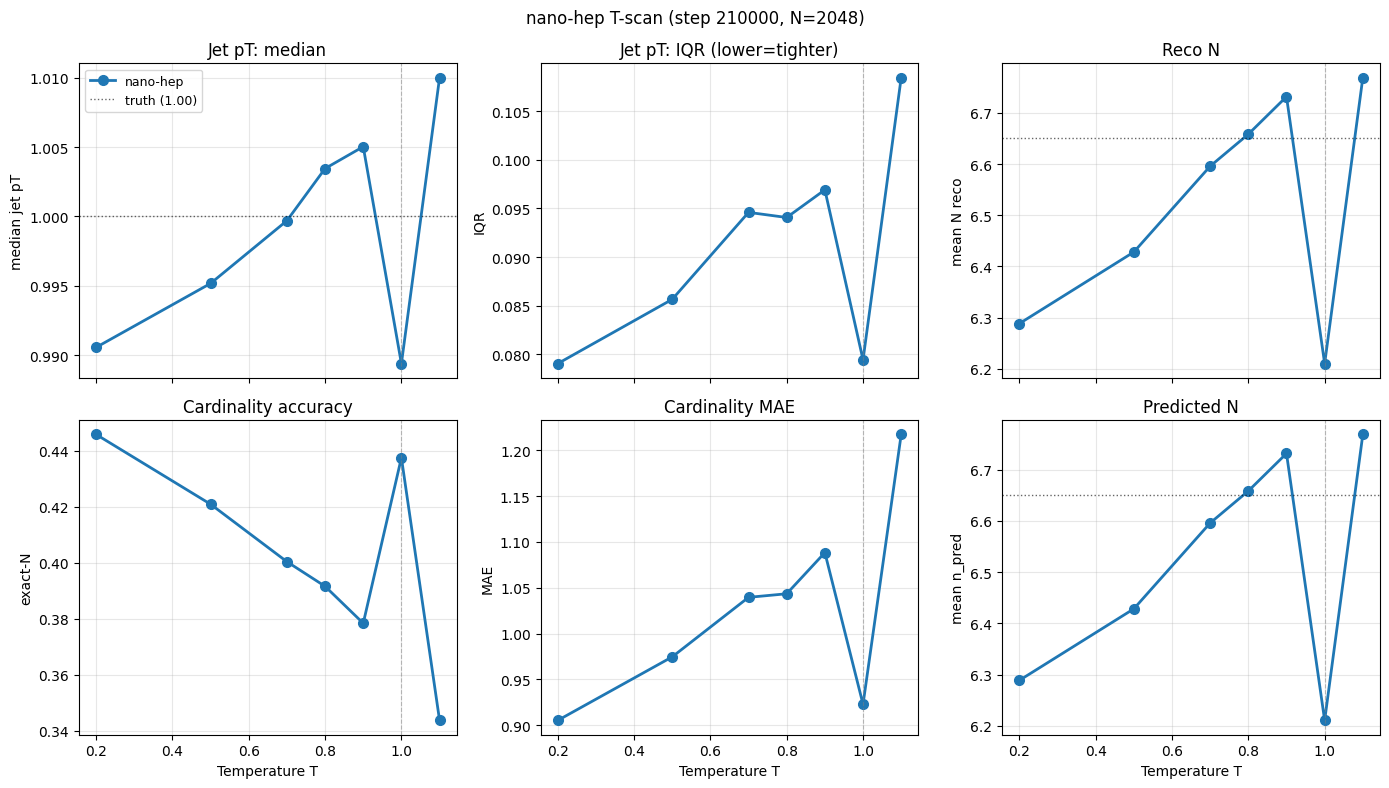

In [27]:
# Nano-hep single-model curves (reload CSV to pick up any manual edits)
if (OUT_NANO / 'nano_hep_T_scan.csv').exists():
    plot_curves(
        pd.read_csv(OUT_NANO / 'nano_hep_T_scan.csv').sort_values('T').reset_index(drop=True),
        'nano-hep', '#1f77b4',
        title_suffix=f' (step {nano_step}, N={N_EVENTS})' if 'nano_step' in dir() else '',
    )

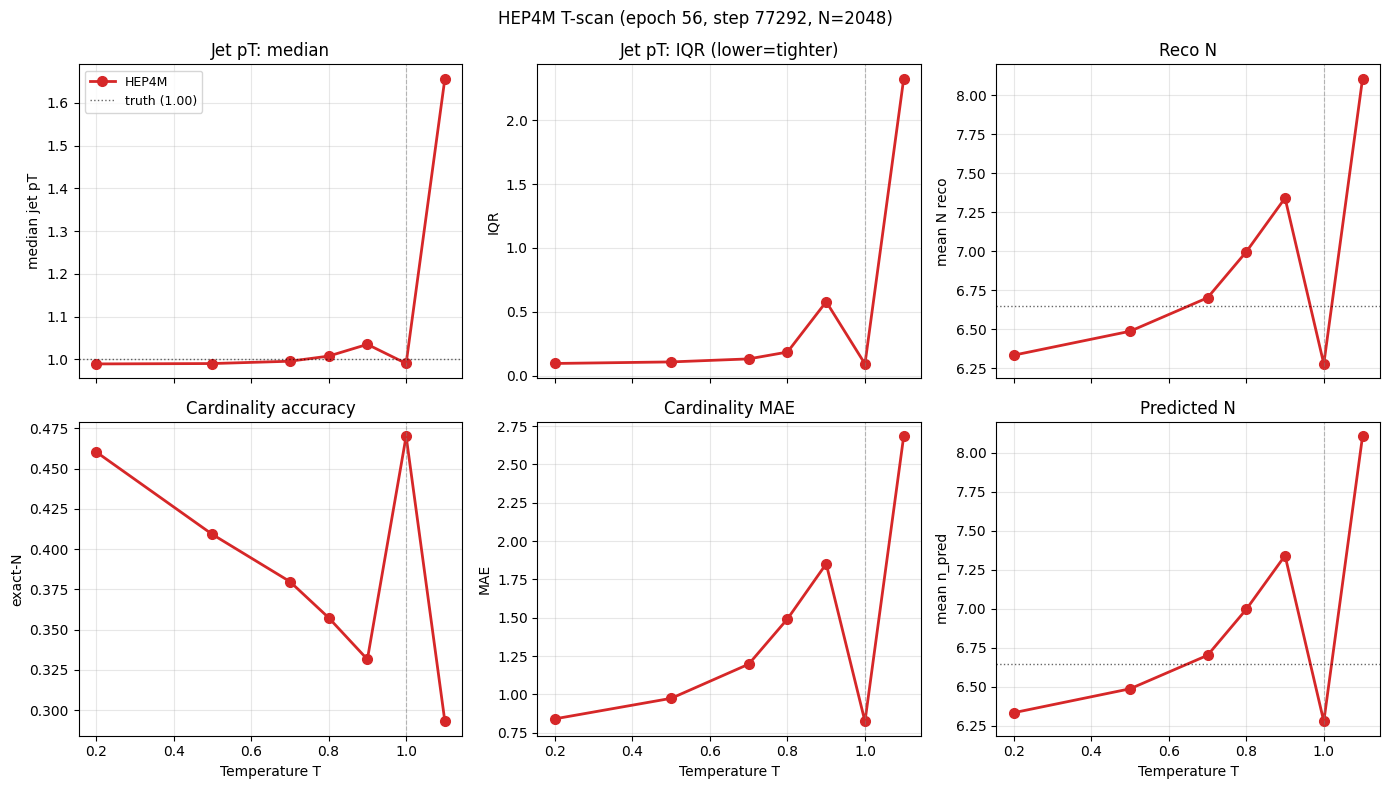

In [28]:
# HEP4M single-model curves
if (OUT_HEP4M / 'hep4m_T_scan.csv').exists():
    plot_curves(
        pd.read_csv(OUT_HEP4M / 'hep4m_T_scan.csv').sort_values('T').reset_index(drop=True),
        'HEP4M', '#d62728',
        title_suffix=f' (epoch {hep4m_epoch}, step {hep4m_gstep}, N={N_EVENTS})' if 'hep4m_epoch' in dir() else '',
    )

## 6. Overlay — needs both CSVs

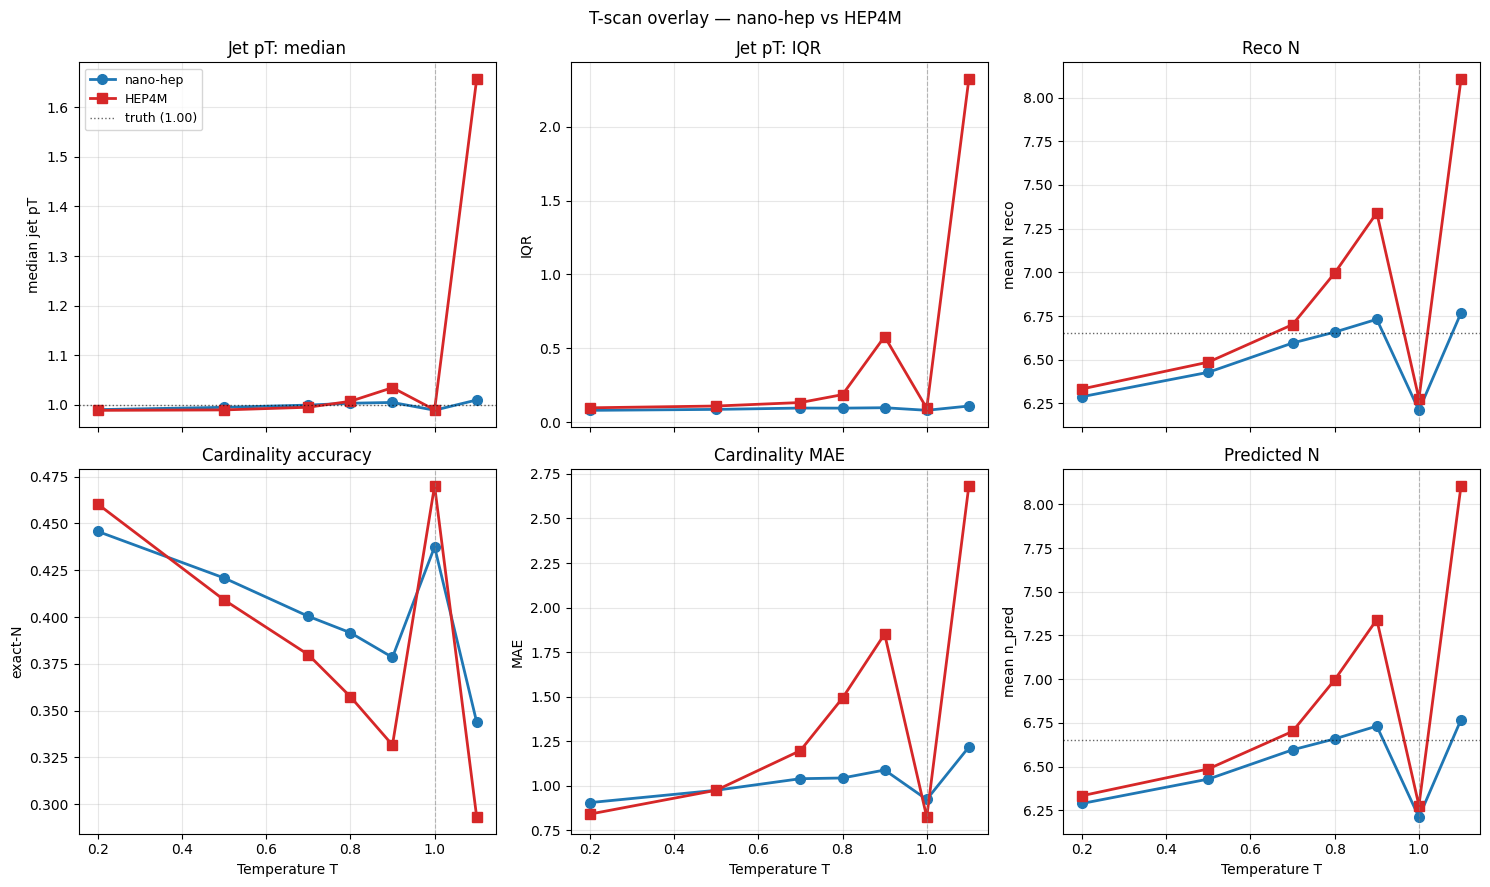

In [29]:
p_nano  = OUT_NANO  / 'nano_hep_T_scan.csv'
p_hep4m = OUT_HEP4M / 'hep4m_T_scan.csv'
if p_nano.exists() and p_hep4m.exists():
    nano_df  = pd.read_csv(p_nano).sort_values('T').reset_index(drop=True)
    hep4m_df = pd.read_csv(p_hep4m).sort_values('T').reset_index(drop=True)
    truth_n = float(nano_df['n_true_mean'].iloc[0])

    fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True)
    def _ov(ax, col, ylabel, title, truth=None):
        ax.plot(nano_df['T'],  nano_df[col],  'o-', color='#1f77b4', lw=2, ms=7, label='nano-hep')
        ax.plot(hep4m_df['T'], hep4m_df[col], 's-', color='#d62728', lw=2, ms=7, label='HEP4M')
        if truth is not None:
            ax.axhline(truth, color='k', ls=':', lw=1, alpha=0.6, label=f'truth ({truth:.2f})')
        ax.axvline(1.0, color='grey', ls='--', lw=0.8, alpha=0.5)
        ax.set_ylabel(ylabel); ax.set_title(title); ax.grid(True, alpha=0.3)
    _ov(axes[0,0], 'pflow_median_jet_pt_response', 'median jet pT', 'Jet pT: median', truth=1.0)
    _ov(axes[0,1], 'pflow_iqr_jet_pt_response', 'IQR', 'Jet pT: IQR')
    _ov(axes[0,2], 'pflow_mean_reco_cardinality_at_threshold', 'mean N reco', 'Reco N', truth=truth_n)
    _ov(axes[1,0], 'cardinality_acc', 'exact-N', 'Cardinality accuracy')
    _ov(axes[1,1], 'cardinality_mae', 'MAE', 'Cardinality MAE')
    _ov(axes[1,2], 'n_pred_mean', 'mean n_pred', 'Predicted N', truth=truth_n)
    axes[0,0].legend(loc='best', fontsize=9)
    for ax in axes[1,:]: ax.set_xlabel('Temperature T')
    fig.suptitle('T-scan overlay — nano-hep vs HEP4M', fontsize=12)
    fig.tight_layout()
else:
    missing = [str(p) for p in (p_nano, p_hep4m) if not p.exists()]
    print('missing CSV(s):', missing)

## 7. Diagnostics — per-event arrays (both models)

Single-T side-by-side diagnostic. Pick a T of interest; we recompute for both models at that T and plot residuals + predicted-vs-truth.

In [10]:
T_PLAY = 1.0

have_nano  = 'nano_model'   in dir()
have_hep4m = 'hep4m_lit'    in dir()

diags = {}
if have_nano:
    r = nano_tts.run_one_T(
        nano_model, nano_vocab, nano_val_ds, T_PLAY, N_EVENTS, device, nano_pflow,
        OUT_NANO, argmax_at_T1=True, seed=SEED,
    )
    diags['nano-hep'] = (np.array(r['_n_pred_arr']), np.array(r['_n_true_arr']), '#1f77b4')
if have_hep4m:
    r = hep4m_tts.run_one_T(
        hep4m_lit, hep4m_loader, hep4m_fixed, T_PLAY, N_EVENTS, device, hep4m_pflow,
        OUT_HEP4M, argmax_at_T1=True, k_token=-1, k_card=-1, seed=SEED,
    )
    diags['HEP4M'] = (np.array(r['_n_pred_arr']), np.array(r['_n_true_arr']), '#d62728')

if not diags:
    print('neither model loaded — run 3a and/or 3b first')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, (npp, ntt, color) in diags.items():
        resid = npp - ntt
        axes[0].hist(resid, bins=range(resid.min()-1, resid.max()+2), alpha=0.5,
                     edgecolor=color, histtype='step', lw=2, label=name)
        axes[1].scatter(ntt, npp, alpha=0.5, s=20, color=color, label=name)
    axes[0].axvline(0, color='k', ls='--', lw=1, alpha=0.5)
    axes[0].set_xlabel('n_pred - n_true'); axes[0].set_title(f'Residual (T={T_PLAY})')
    axes[0].grid(alpha=0.3); axes[0].legend()
    lim = max(max(d[0].max(), d[1].max()) for d in diags.values()) + 1
    axes[1].plot([0, lim], [0, lim], 'k--', alpha=0.5)
    axes[1].set_xlabel('n_true'); axes[1].set_ylabel('n_pred')
    axes[1].set_title('Predicted vs truth'); axes[1].grid(alpha=0.3); axes[1].legend()
    fig.tight_layout()

KeyboardInterrupt: 

## 8. Free-form — all modules + models live here

You have access to: `nano_model/nano_vocab/nano_val_ds/nano_pflow` (if loaded), `hep4m_lit/hep4m_loader/hep4m_fixed/hep4m_pflow` (if loaded), both `nano_tts` and `hep4m_tts` modules.

In [8]:
# Example: peek at a single-event AR decode for nano-hep
if 'nano_model' in dir():
    pc, pp = nano_tts.ar_decode_tempered(
        nano_model, nano_vocab, nano_val_ds, 0, T=1.0,
        max_new_tokens=nano_val_ds.block_size, device=device, argmax_at_T1=True,
    )
    n_true = int(nano_val_ds.out_mm.offsets[1] - nano_val_ds.out_mm.offsets[0])
    print(f'nano event 0: pred_n={pc.shape[0]}  true_n={n_true}')
else:
    print('nano-hep not loaded')

nano event 0: pred_n=5  true_n=5


## 9. N-head-assisted decoding — `free` vs `floor` vs `force` (nano-hep only)

Compares three decoding modes on the same nano-hep checkpoint at T=1 argmax. Requires a `GPTWithNHead` checkpoint.

- **free**  — plain EOS termination (current AR behavior)
- **floor** — mask EOS until ≥ 6·N̂ tokens emitted, then allow EOS (raises cardinality floor; can't lower)
- **force** — mask EOS always, stop exactly at 6·N̂ tokens (locks n_pred = N̂)

In [6]:
import pickle

# Cache keyed by nano-hep training step — re-runs only when the checkpoint
# advances. Set FORCE_RECOMPUTE_NH = True to ignore cache.
FORCE_RECOMPUTE_NH = False
_nh_cache = (OUT_NANO / f'nhead_modes_step{nano_step}.pkl') if 'nano_step' in dir() else None

if 'nano_model' in dir() and hasattr(nano_model, 'n_head_mlp'):
    T_NH = 1.0
    modes = ('free', 'floor', 'force')
    if _nh_cache is not None and _nh_cache.exists() and not FORCE_RECOMPUTE_NH:
        print(f'[cache] loading N-head mode results from {_nh_cache.name}')
        with open(_nh_cache, 'rb') as f:
            results_nh = pickle.load(f)
    else:
        results_nh = {}
        for mode in modes:
            print(f'--- nano-hep mode = {mode} (T={T_NH}) ---', flush=True)
            results_nh[mode] = run_one_T_batched(
                nano_model, nano_vocab, nano_val_ds, T_NH, N_EVENTS, device,
                nano_pflow, OUT_NANO, argmax_at_T1=True, seed=SEED, nhead_mode=mode,
            )
            r = results_nh[mode]
            for k in ('cardinality_acc', 'cardinality_mae',
                      'pflow_median_jet_pt_response', 'pflow_iqr_jet_pt_response',
                      'pflow_mean_reco_cardinality_at_threshold'):
                if k in r: print(f'  {k}: {r[k]:.4f}')
        if _nh_cache is not None:
            with open(_nh_cache, 'wb') as f:
                pickle.dump(results_nh, f)
            print(f'[cache] saved -> {_nh_cache.name}')

    df_nh = pd.DataFrame([
        {'mode': m, **{k: v for k, v in results_nh[m].items() if not k.startswith('_')}}
        for m in modes
    ])
    display(df_nh[['mode', 'cardinality_acc', 'cardinality_mae',
                   'pflow_median_jet_pt_response', 'pflow_iqr_jet_pt_response',
                   'pflow_mean_reco_cardinality_at_threshold', 'n_pred_mean']])
else:
    print('nano-hep not loaded or checkpoint lacks N-head (no n_head_mlp module).')

[cache] loading N-head mode results from nhead_modes_step495000.pkl


,mode,cardinality_acc,cardinality_mae,pflow_median_jet_pt_response,pflow_iqr_jet_pt_response,pflow_mean_reco_cardinality_at_threshold,n_pred_mean
0,free,0.460938,0.921875,0.981279,0.071275,6.140625,6.140625
1,floor,0.492188,0.796875,0.985376,0.084335,6.359375,6.359375
2,force,0.492188,0.796875,0.981136,0.088851,6.218750,6.218750


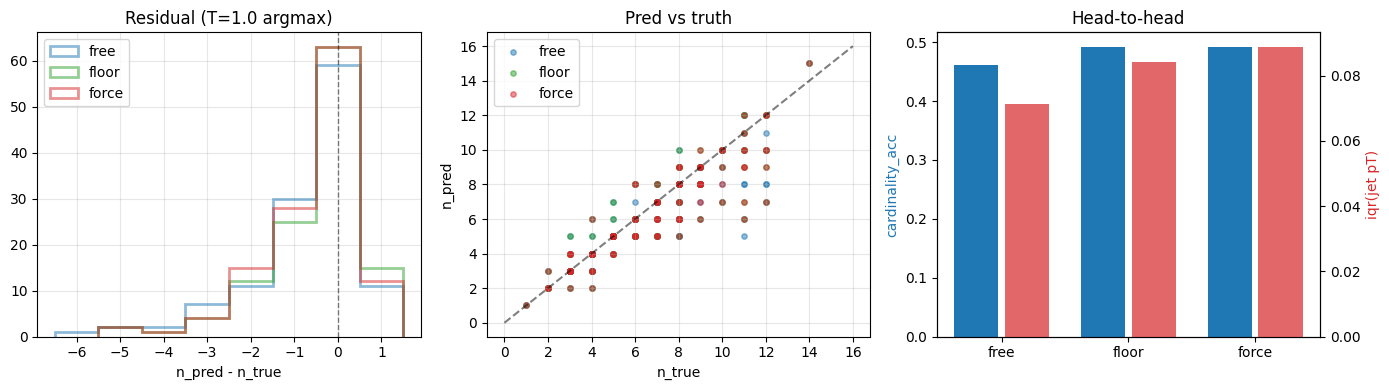

In [7]:
if 'results_nh' in dir():
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    colors = {'free': '#1f77b4', 'floor': '#2ca02c', 'force': '#d62728'}
    truth_n = float(np.array(results_nh['free']['_n_true_arr']).mean())
    for name, r in results_nh.items():
        n_pred = np.array(r['_n_pred_arr'])
        n_true = np.array(r['_n_true_arr'])
        resid  = n_pred - n_true
        axes[0].hist(resid, bins=np.arange(resid.min()-0.5, resid.max()+0.5), alpha=0.5,
                        edgecolor=colors[name], histtype='step', lw=2, label=name)
        axes[1].scatter(n_true, n_pred, alpha=0.5, s=15, color=colors[name], label=name)
    axes[0].axvline(0, color='k', ls='--', lw=1, alpha=0.5)
    axes[0].set_xlabel('n_pred - n_true'); axes[0].set_title(f'Residual (T={T_NH} argmax)'); axes[0].grid(alpha=0.3); axes[0].legend()
    lim = max(np.array(r['_n_pred_arr']).max() for r in results_nh.values()) + 1
    lim = max(lim, int(truth_n * 2))
    axes[1].plot([0, lim], [0, lim], 'k--', alpha=0.5)
    axes[1].set_xlabel('n_true'); axes[1].set_ylabel('n_pred')
    axes[1].set_title('Pred vs truth'); axes[1].grid(alpha=0.3); axes[1].legend()
    # Metric comparison bar chart
    modes = list(results_nh.keys())
    accs = [results_nh[m]['cardinality_acc'] for m in modes]
    iqrs = [results_nh[m].get('pflow_iqr_jet_pt_response', np.nan) for m in modes]
    x = np.arange(len(modes))
    axes[2].bar(x - 0.2, accs, width=0.35, color='#1f77b4', label='card_acc')
    ax2t = axes[2].twinx()
    ax2t.bar(x + 0.2, iqrs, width=0.35, color='#d62728', label='iqr', alpha=0.7)
    axes[2].set_xticks(x); axes[2].set_xticklabels(modes)
    axes[2].set_ylabel('cardinality_acc', color='#1f77b4')
    ax2t.set_ylabel('iqr(jet pT)', color='#d62728')
    axes[2].set_title('Head-to-head')
    fig.tight_layout()
    plt.show()

In [25]:
plt.show()

## 10. Jet pT-response distribution — per decoding mode + HEP4M

Overlay histogram of per-event `jet_pt_reco / jet_pt_truth` for the three nano-hep modes (free, floor, force) and HEP4M at T=1 argmax. A sharper, more centered-on-1 distribution means better jet-level reconstruction. Requires nano-hep with N-head and HEP4M both loaded, and assumes section 9 has run (so `results_nh` exists).

[cache] loading jet+card series from jet_card_series_nano495000_hep363408_T1.0.pkl


,mode,n_jets,jet_median,jet_iqr,jet_mae_resp,card_acc,card_mae,card_bias
0,nano-hep · free,128,0.981279,0.071275,0.054721,0.460938,0.921875,-0.593750
1,nano-hep · floor,128,0.985376,0.084335,0.057678,0.492188,0.796875,-0.375000
2,nano-hep · force,128,0.981136,0.088851,0.062595,0.492188,0.796875,-0.515625
3,HEP4M · argmax,128,1.004522,0.091379,0.057207,0.507812,0.695312,-0.164062


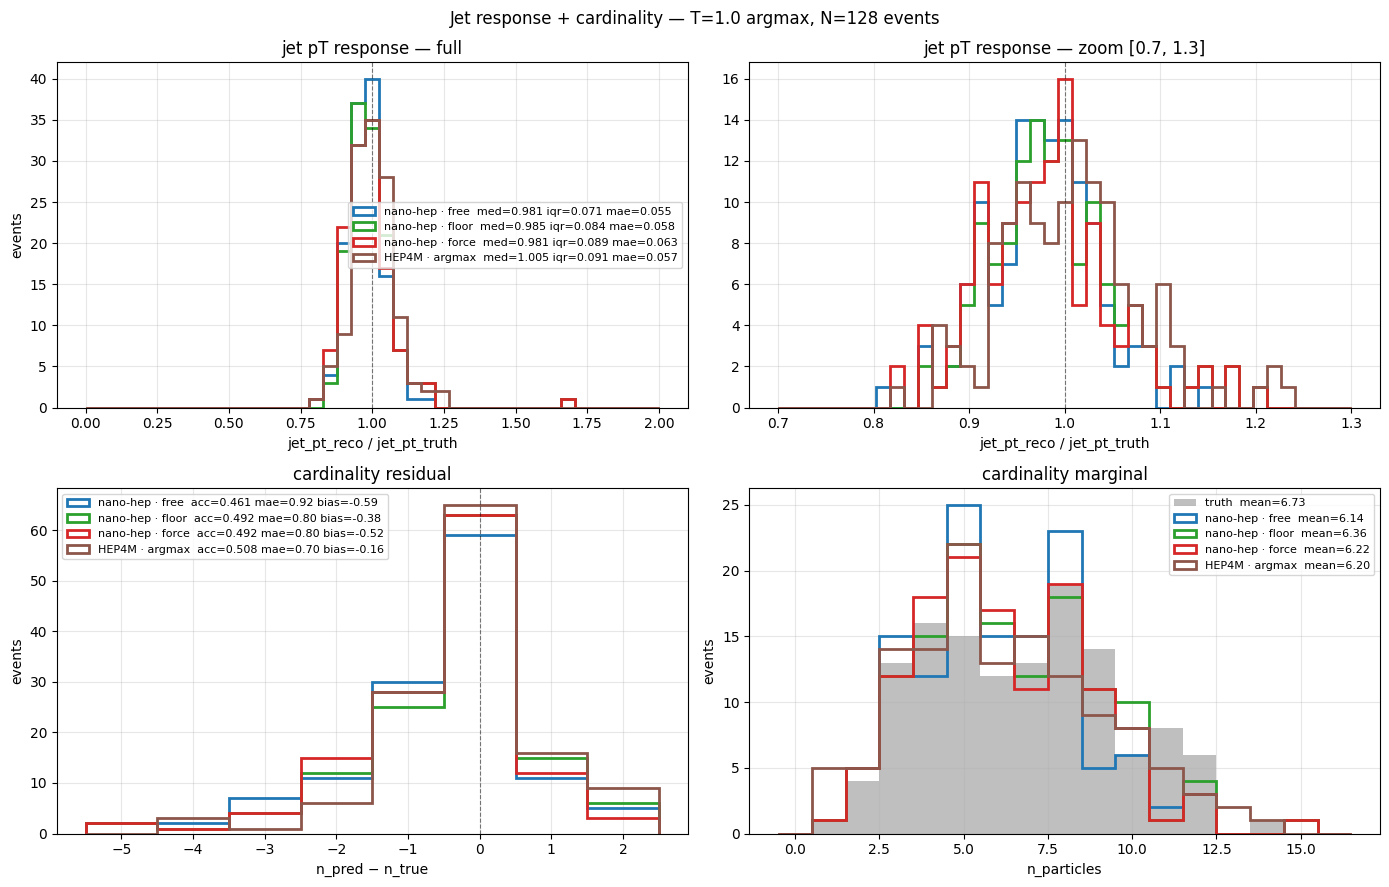

In [9]:
# Jet pT-response overlay + cardinality comparison.
# Four-panel figure:
#   (0,0) jet pT response — full range
#   (0,1) jet pT response — zoom [0.7, 1.3]
#   (1,0) cardinality residual  (n_pred - n_true)
#   (1,1) cardinality marginal  (n_pred vs shared n_true)
import pickle
T_JET = 1.0

FORCE_RECOMPUTE_JET = False
_jet_tag = f"nano{nano_step if 'nano_step' in dir() else 'na'}_hep{hep4m_gstep if 'hep4m_gstep' in dir() else 'na'}_T{T_JET}"
_jet_cache = OUT_NANO / f'jet_card_series_{_jet_tag}.pkl'

def _resp_from_jt(jt):
    if jt is None: return None
    for k in ("pt_response", "jet_pt_response", "jet_response", "response"):
        if k in jt: return np.asarray(jt[k], dtype=float)
    if "reco_pt" in jt and "truth_pt" in jt:
        r = np.asarray(jt["reco_pt"], dtype=float); t = np.asarray(jt["truth_pt"], dtype=float)
        m = t > 0
        return r[m] / t[m]
    return None

def _card_from_result(res):
    if res is None: return None, None
    n_pred = res.get("_n_pred_arr"); n_true = res.get("_n_true_arr")
    if n_pred is None or n_true is None: return None, None
    return np.asarray(n_pred, dtype=int), np.asarray(n_true, dtype=int)

if _jet_cache.exists() and not FORCE_RECOMPUTE_JET:
    print(f'[cache] loading jet+card series from {_jet_cache.name}')
    with open(_jet_cache, 'rb') as f:
        _cached = pickle.load(f)
    jet_series  = _cached['jet_series']
    card_series = _cached['card_series']
else:
    jet_series  = {}
    card_series = {}
    if 'results_nh' in dir():
        for m, res in results_nh.items():
            s = _resp_from_jt(res.get("_jet_table"))
            if s is not None:
                jet_series[f"nano-hep · {m}"] = s
            n_p, n_t = _card_from_result(res)
            if n_p is not None:
                card_series[f"nano-hep · {m}"] = (n_p, n_t)
    if 'hep4m_lit' in dir():
        r_h = hep4m_tts.run_one_T(
            hep4m_lit, hep4m_loader, hep4m_fixed, T_JET, N_EVENTS, device,
            hep4m_pflow, OUT_HEP4M, argmax_at_T1=True, k_token=-1, k_card=-1, seed=SEED,
        )
        s = _resp_from_jt(r_h.get("_jet_table"))
        if s is not None:
            jet_series["HEP4M · argmax"] = s
        n_p, n_t = _card_from_result(r_h)
        if n_p is not None:
            card_series["HEP4M · argmax"] = (n_p, n_t)
    if jet_series or card_series:
        with open(_jet_cache, 'wb') as f:
            pickle.dump({'jet_series': jet_series, 'card_series': card_series}, f)
        print(f'[cache] saved -> {_jet_cache.name}')

palette = {
    'nano-hep · free':  '#1f77b4',
    'nano-hep · floor': '#2ca02c',
    'nano-hep · force': '#d62728',
    'HEP4M · argmax':   '#8c564b',
}

if not jet_series and not card_series:
    print("no series computed. Diagnostic:")
    def _probe(label, res):
        if res is None: return f"  {label}: no result"
        jt = res.get("_jet_table")
        return (f"  {label}: _jet_table {'missing (stale run_one_T? re-run cell 2 then section 9)' if jt is None else 'ok'}"
                f"  n_pred_arr={'ok' if res.get('_n_pred_arr') is not None else 'missing'}")
    if 'results_nh' in dir():
        for m, res in results_nh.items(): print(_probe(f"nano-hep · {m}", res))
    if 'r_h' in dir(): print(_probe("HEP4M · argmax", r_h))
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    bins_full = np.linspace(0, 2.0, 42)
    bins_zoom = np.linspace(0.7, 1.3, 42)
    summary_rows = []

    # Row 0: jet pT response
    for name, s in jet_series.items():
        c = palette.get(name, None)
        med = float(np.median(s)); iqr = float(np.subtract(*np.percentile(s, [75, 25])))
        mae = float(np.mean(np.abs(s - 1.0)))
        axes[0, 0].hist(s, bins=bins_full, histtype='step', lw=2,
                        label=f"{name}  med={med:.3f} iqr={iqr:.3f} mae={mae:.3f}", color=c)
        axes[0, 1].hist(s, bins=bins_zoom, histtype='step', lw=2, color=c)
        summary_rows.append({'mode': name, 'n_jets': len(s),
                             'jet_median': med, 'jet_iqr': iqr, 'jet_mae_resp': mae})

    # Row 1: cardinality
    if card_series:
        resid_min = min(int((n_p - n_t).min()) for n_p, n_t in card_series.values())
        resid_max = max(int((n_p - n_t).max()) for n_p, n_t in card_series.values())
        # resid_bins = np.arange(resid_min - 0.5, resid_max + 1.5, 1.0)
        resid_bins = np.arange(-5.5, 3.5, 1.0)  # fixed range for better visual comparison across modes
        for name, (n_p, n_t) in card_series.items():
            c = palette.get(name, None)
            resid = n_p - n_t
            acc = float((resid == 0).mean())
            mae_n = float(np.abs(resid).mean())
            bias_n = float(resid.mean())
            axes[1, 0].hist(resid, bins=resid_bins, histtype='step', lw=2, color=c,
                            label=f"{name}  acc={acc:.3f} mae={mae_n:.2f} bias={bias_n:+.2f}")
            for r in summary_rows:
                if r['mode'] == name:
                    r['card_acc'] = acc; r['card_mae'] = mae_n; r['card_bias'] = bias_n

        # Marginal: all predictions + shared truth as filled reference
        n_true_ref = next(iter(card_series.values()))[1]
        n_max = max(int(max(n_p.max() for n_p, _ in card_series.values())),
                    int(n_true_ref.max())) + 1
        marg_bins = np.arange(-0.5, n_max + 1.5, 1.0)
        axes[1, 1].hist(n_true_ref, bins=marg_bins, alpha=0.25, color='k',
                        label=f'truth  mean={n_true_ref.mean():.2f}')
        for name, (n_p, _) in card_series.items():
            c = palette.get(name, None)
            axes[1, 1].hist(n_p, bins=marg_bins, histtype='step', lw=2, color=c,
                            label=f"{name}  mean={n_p.mean():.2f}")

    # Polish
    axes[0, 0].axvline(1.0, color='k', ls='--', lw=0.8, alpha=0.5)
    axes[0, 1].axvline(1.0, color='k', ls='--', lw=0.8, alpha=0.5)
    axes[1, 0].axvline(0.0, color='k', ls='--', lw=0.8, alpha=0.5)
    axes[0, 0].set_title('jet pT response — full');    axes[0, 0].set_xlabel('jet_pt_reco / jet_pt_truth'); axes[0, 0].set_ylabel('events')
    axes[0, 1].set_title('jet pT response — zoom [0.7, 1.3]'); axes[0, 1].set_xlabel('jet_pt_reco / jet_pt_truth')
    axes[1, 0].set_title('cardinality residual');      axes[1, 0].set_xlabel('n_pred − n_true'); axes[1, 0].set_ylabel('events')
    axes[1, 1].set_title('cardinality marginal');      axes[1, 1].set_xlabel('n_particles'); axes[1, 1].set_ylabel('events')
    for ax in axes.flat: ax.grid(alpha=0.3)
    axes[0, 0].legend(loc='best', fontsize=8)
    axes[1, 0].legend(loc='best', fontsize=8)
    axes[1, 1].legend(loc='best', fontsize=8)
    fig.suptitle(f'Jet response + cardinality — T={T_JET} argmax, N={N_EVENTS} events', fontsize=12)
    fig.tight_layout()
    display(pd.DataFrame(summary_rows))

## 11. Top-k ablation on each HEP4M softmax — cardinality / content / position

Fixing T=1 (deterministic softmax) and turning OFF the argmax override, we sample from `top_k` of each of the THREE independently-controllable HEP4M softmaxes:

- **k_card**    — cardinality head in two-step inference (how many particles to emit).
- **k_content** — per-slot content-token VQ code sampling.
- **k_pos**     — per-slot gpos-token (eta, cos φ, sin φ) sampling.

At k=1 each is argmax. At k=V (or -1) it's the full distribution. We scan each axis independently while the other two stay at k=1 (argmax). Only the scanned axis is stochastic, so any MC noise in the ablation comes from that single softmax.

Three plots per scan: jet_pt_MAE (response), cardinality_acc, ar_content_token_acc. HEP4M only (two-step architecture); for nano-hep the three softmaxes share a single AR stream so this decomposition doesn't cleanly apply.

In [ ]:
# HEP4M top-k ablation: scan each of k_card / k_content / k_pos independently.
# Cached by (hep4m_gstep, N_EVENTS) so re-running is cheap once computed.
import pickle
FORCE_RECOMPUTE_TOPK = False
K_GRID = [1, 2, 3, 5, 10, -1]   # -1 = full distribution

if 'hep4m_lit' not in dir():
    print("HEP4M not loaded — run section 3b first.")
else:
    _topk_tag = f"hep{hep4m_gstep}_N{N_EVENTS}"
    _topk_cache = OUT_HEP4M / f'topk_ablation_{_topk_tag}.pkl'

    def _resp_mae(res):
        jt = res.get('_jet_table') or {}
        pt_resp = np.asarray(jt.get('pt_response', []), dtype=float)
        return float(np.mean(np.abs(pt_resp - 1.0))) if pt_resp.size else float('nan')

    def _run(k_card, k_content, k_pos):
        # argmax_at_T1=False so the monkey-patch activates top-k sampling
        # rather than short-circuiting to logits.argmax. T=1 is neutral.
        return hep4m_tts.run_one_T(
            hep4m_lit, hep4m_loader, hep4m_fixed, T=1.0,
            n_events=N_EVENTS, device=device, pflow=hep4m_pflow, out_dir=OUT_HEP4M,
            argmax_at_T1=False,
            k_card=k_card, k_token=k_content, k_gpos=k_pos,
            seed=SEED,
        )

    if _topk_cache.exists() and not FORCE_RECOMPUTE_TOPK:
        print(f'[cache] loading top-k ablation from {_topk_cache.name}')
        with open(_topk_cache, 'rb') as f:
            topk_results = pickle.load(f)
    else:
        topk_results = {'k_card': [], 'k_content': [], 'k_pos': []}
        # Baseline anchor: all three at 1 (argmax-equivalent) — shows up as
        # the k=1 point in every scan, same value each time.
        print("--- scan k_card (k_content=8, k_pos=1) ---", flush=True)
        for k in K_GRID:
            t0 = time.time()
            r = _run(k_card=k, k_content=8, k_pos=1)
            topk_results['k_card'].append({
                'k': k, 'jet_mae_resp': _resp_mae(r),
                'cardinality_acc': r['cardinality_acc'],
                'cardinality_mae': r['cardinality_mae'],
                'n_pred_mean':     r['n_pred_mean'],
            })
            print(f"  k_card={k:>3}  jet_mae={_resp_mae(r):.3f}  "
                  f"card_acc={r['cardinality_acc']:.3f}  "
                  f"card_mae={r['cardinality_mae']:.2f}  [{time.time()-t0:.1f}s]")
        print("--- scan k_content (k_card=1, k_pos=1) ---", flush=True)
        for k in K_GRID:
            t0 = time.time()
            r = _run(k_card=1, k_content=k, k_pos=1)
            topk_results['k_content'].append({
                'k': k, 'jet_mae_resp': _resp_mae(r),
                'cardinality_acc': r['cardinality_acc'],
                'cardinality_mae': r['cardinality_mae'],
                'n_pred_mean':     r['n_pred_mean'],
            })
            print(f"  k_content={k:>3}  jet_mae={_resp_mae(r):.3f}  "
                  f"card_acc={r['cardinality_acc']:.3f}  "
                  f"card_mae={r['cardinality_mae']:.2f}  [{time.time()-t0:.1f}s]")
        print("--- scan k_pos (k_card=1, k_content=1) ---", flush=True)
        for k in K_GRID:
            t0 = time.time()
            r = _run(k_card=1, k_content=1, k_pos=k)
            topk_results['k_pos'].append({
                'k': k, 'jet_mae_resp': _resp_mae(r),
                'cardinality_acc': r['cardinality_acc'],
                'cardinality_mae': r['cardinality_mae'],
                'n_pred_mean':     r['n_pred_mean'],
            })
            print(f"  k_pos={k:>3}  jet_mae={_resp_mae(r):.3f}  "
                  f"card_acc={r['cardinality_acc']:.3f}  "
                  f"card_mae={r['cardinality_mae']:.2f}  [{time.time()-t0:.1f}s]")

        with open(_topk_cache, 'wb') as f:
            pickle.dump(topk_results, f)
        print(f'[cache] saved -> {_topk_cache.name}')

    # Tables for inspection
    for axis in ('k_card', 'k_content', 'k_pos'):
        display(pd.DataFrame(topk_results[axis]).assign(scan=axis)
                  [['scan','k','jet_mae_resp','cardinality_acc','cardinality_mae','n_pred_mean']])

--- scan k_card (k_content=8, k_pos=1) ---


  [T=1.0] fast_forward 2048 events in 2.7s
  k_card=  1  jet_mae=0.092  card_acc=0.470  card_mae=0.82  [4.1s]
  [T=1.0] fast_forward 2048 events in 2.7s
  k_card=  2  jet_mae=0.089  card_acc=0.405  card_mae=0.90  [4.1s]
  [T=1.0] fast_forward 2048 events in 2.7s
  k_card=  3  jet_mae=0.095  card_acc=0.386  card_mae=0.96  [4.0s]
  [T=1.0] fast_forward 2048 events in 2.7s
  k_card=  5  jet_mae=0.094  card_acc=0.375  card_mae=1.04  [4.1s]
  [T=1.0] fast_forward 2048 events in 2.7s
  k_card= 10  jet_mae=0.102  card_acc=0.351  card_mae=1.21  [4.0s]
  [T=1.0] fast_forward 2048 events in 2.6s
  k_card= -1  jet_mae=0.161  card_acc=0.324  card_mae=2.09  [4.1s]
--- scan k_content (k_card=1, k_pos=1) ---
  [T=1.0] fast_forward 2048 events in 2.6s
  k_content=  1  jet_mae=0.063  card_acc=0.470  card_mae=0.82  [4.0s]
  [T=1.0] fast_forward 2048 events in 2.6s
  k_content=  2  jet_mae=0.070  card_acc=0.470  card_mae=0.82  [4.9s]
  [T=1.0] fast_forward 2048 events in 2.6s
  k_content=  3  jet_mae=0.0

,scan,k,jet_mae_resp,cardinality_acc,cardinality_mae,n_pred_mean
0,k_card,1,0.091689,0.470215,0.823730,6.276855
1,k_card,2,0.089442,0.404785,0.898438,6.385742
2,k_card,3,0.094656,0.385742,0.958984,6.450195
3,k_card,5,0.094289,0.375000,1.037109,6.509766
4,k_card,10,0.101813,0.351074,1.211426,6.719238
5,k_card,-1,0.161134,0.323730,2.094727,7.471680


,scan,k,jet_mae_resp,cardinality_acc,cardinality_mae,n_pred_mean
0,k_content,1,0.062970,0.470215,0.82373,6.276855
1,k_content,2,0.070245,0.470215,0.82373,6.276855
2,k_content,3,0.071797,0.470215,0.82373,6.276855
3,k_content,5,0.080501,0.470215,0.82373,6.276855
4,k_content,10,0.101034,0.470215,0.82373,6.276855
5,k_content,-1,1.090829,0.470215,0.82373,6.276855


,scan,k,jet_mae_resp,cardinality_acc,cardinality_mae,n_pred_mean
0,k_pos,1,0.062970,0.470215,0.82373,6.276855
1,k_pos,2,0.063114,0.470215,0.82373,6.276855
2,k_pos,3,0.064895,0.470215,0.82373,6.276855
3,k_pos,5,0.065924,0.470215,0.82373,6.276855
4,k_pos,10,0.066396,0.470215,0.82373,6.276855
5,k_pos,-1,0.115714,0.470215,0.82373,6.276855


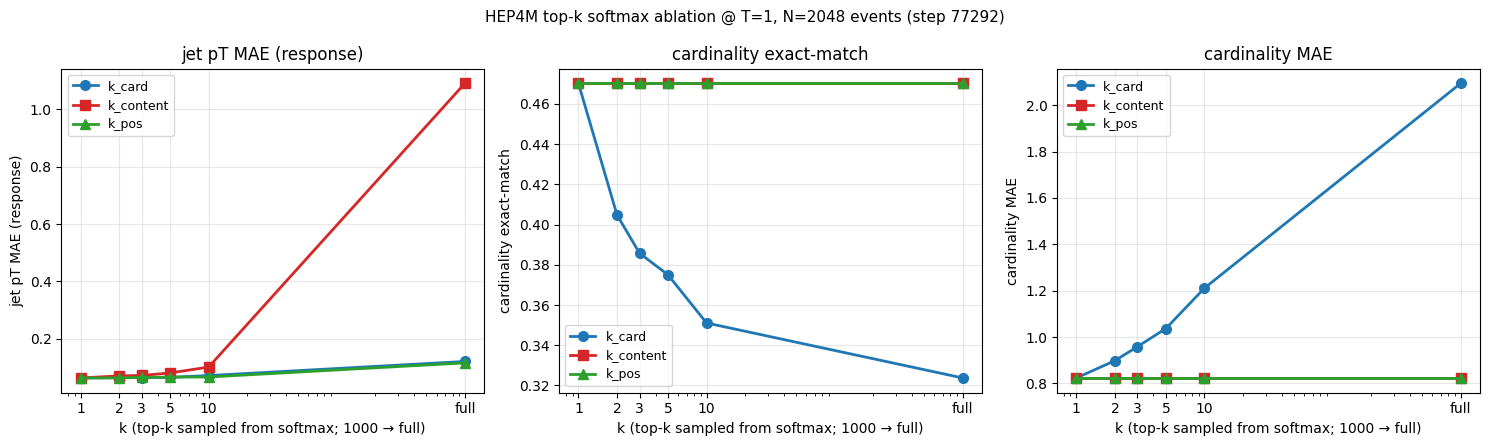

In [ ]:
# Overlay the three scans on shared axes.
if 'topk_results' in dir():
    # Render -1 ("full") as the largest x for plotting; label it in the ticks.
    def _k_to_x(k):
        return 1000 if k == -1 else k

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    colors = {'k_card': '#1f77b4', 'k_content': '#d62728', 'k_pos': '#2ca02c'}
    markers = {'k_card': 'o', 'k_content': 's', 'k_pos': '^'}

    metric_cols = [
        ('jet_mae_resp',    'jet pT MAE (response)',   axes[0]),
        ('cardinality_acc', 'cardinality exact-match', axes[1]),
        ('cardinality_mae', 'cardinality MAE',         axes[2]),
    ]
    for axis_name in ('k_card', 'k_content', 'k_pos'):
        df_s = pd.DataFrame(topk_results[axis_name]).sort_values('k',
                   key=lambda s: s.map(_k_to_x)).reset_index(drop=True)
        xs = [_k_to_x(k) for k in df_s['k']]
        for col, ylabel, ax in metric_cols:
            ax.plot(xs, df_s[col], color=colors[axis_name],
                    marker=markers[axis_name], lw=2, ms=7, label=axis_name)
    for col, ylabel, ax in metric_cols:
        ax.set_xscale('log')
        ax.set_xlabel('k (top-k sampled from softmax; 1000 → full)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_title(ylabel)
    # Custom x-ticks to show the 'full' label
    xticks = [1, 2, 3, 5, 10, 1000]
    xticklabels = ['1', '2', '3', '5', '10', 'full']
    for _, _, ax in metric_cols:
        ax.set_xticks(xticks); ax.set_xticklabels(xticklabels)
    fig.suptitle(f'HEP4M top-k softmax ablation @ T=1, N={N_EVENTS} events '
                 f'(step {hep4m_gstep})', fontsize=11)
    fig.tight_layout()
else:
    print("run the top-k ablation cell above first.")